# Questions
- Utiliser le fichier test que pour la meilleure méthode ou pour l'évaluation de chacune d'entre elles ?
- Utiliser cv pour les baseslines ? (meme protocole d'évaluation que les méthdoes)
- "Analyse du déséquilibre éventuel" ?

# TO DO

- Méthode C
- Analyse des résultats
- README
- figure
- Analyse du désquilibre ?

In [181]:
import pandas as pd

# Analyse
from collections import Counter, defaultdict
import re

# Specifité par classe
from collections import Counter
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords


# BaseLine
from sklearn.dummy import DummyClassifier

# Evaluation méthodes
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Méthodes
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Méthode B
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Méthode C
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer

# Plots
import os
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\33784\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [150]:
test = pd.read_csv("../data/test.csv")
train = pd.read_csv("../data/train.csv")

In [151]:
# TF-IDF ne peut prendre qu'un seul champ en entrée
# df["text"] = données concatenees par avec des espaces.

for df in (train, test):
    df["text"] = (
        df["titre"].fillna("") + " " +
        df["ingredients"].fillna("") + " " +
        df["recette"].fillna("")
    )



# Exploration des données

In [152]:
print("Exploration des données\n")

print("Nombre de documents par sous-ensemble:")
print("Train:", train.shape, "\nTest:", test.shape)

print("\nRépartition des classes (train):")
print(train["type"].value_counts())
print(" En pourecentage:")
print(train["type"].value_counts(normalize=True) * 100)


Exploration des données

Nombre de documents par sous-ensemble:
Train: (12473, 8) 
Test: (1388, 8)

Répartition des classes (train):
type
Plat principal    5802
Dessert           3762
Entrée            2909
Name: count, dtype: int64
 En pourecentage:
type
Plat principal    46.516476
Dessert           30.161148
Entrée            23.322376
Name: proportion, dtype: float64


In [153]:
# On compte le nombre de mots et affiche les stats sur ces longueurs.
print("\nLongueur (mots) - stats:")
for col in ["ingredients", "recette", "text"]:
    print("Longueur", col, ":")
    print(train[col].str.split().apply(len).describe(), "\n")


Longueur (mots) - stats:
Longueur ingredients :
count    12473.000000
mean        47.168444
std         21.263231
min          7.000000
25%         33.000000
50%         43.000000
75%         57.000000
max        232.000000
Name: ingredients, dtype: float64 

Longueur recette :
count    12473.000000
mean       123.551431
std         67.825932
min          9.000000
25%         81.000000
50%        109.000000
75%        149.000000
max       1334.000000
Name: recette, dtype: float64 

Longueur text :
count    12473.000000
mean       175.846949
std         81.010377
min         25.000000
25%        124.000000
50%        159.000000
75%        209.000000
max       1450.000000
Name: text, dtype: float64 



- count = 12473 : 12 473 recettes
- mean = 175.85 : en moyenne, une ligne fait ~176 mots.
- std = 81.01 : l’écart-type (dispersion).
- min = 25 : la plus courte ligne a 25 mots.

### Spécificités lexicales par classe

In [154]:
french_stopwords = set(stopwords.words("french"))

def tokenize(text, strip_accents=False):
    """
    Tokenisation :
    - minuscule
    - suppression des élisions fréquentes : d', l', qu', ...
    - extraction des mots
    - suppression des stopwords français
    - suppression des tokens trop courts
    """
    if not isinstance(text, str):
        return []

    text = text.lower()

    # enlève les élisions fréquentes : d'asperge -> asperge, l'avocat -> avocat
    text = re.sub(r"\b(?:d|l|j|m|n|s|t|c|qu)'", "", text)

    # extrait les mots alphabétiques (avec accents et tirets)
    tokens = re.findall(r"[a-zàâçéèêëîïôûùüÿñæœ]+(?:-[a-zàâçéèêëîïôûùüÿñæœ]+)*", text)

    stopwords_set = french_stopwords

    # filtre stopwords + longueur minimale
    tokens = [
        tok for tok in tokens
        if len(tok) >= 3 and tok not in stopwords_set
    ]

    return tokens

In [155]:
def top_specific_words_by_class(df, text_col="text", label_col="type", top_n=15, min_freq=5):
    results = {}

    # tokens de tout le corpus
    all_tokens = df[text_col].fillna("").apply(tokenize)

    for classe in sorted(df[label_col].unique()):
        mask = df[label_col] == classe

        class_tokens = [tok for doc in all_tokens[mask] for tok in doc]
        other_tokens = [tok for doc in all_tokens[~mask] for tok in doc]

        class_counts = Counter(class_tokens)
        other_counts = Counter(other_tokens)

        total_class = sum(class_counts.values())
        total_other = sum(other_counts.values())

        scores = []
        vocab = set(class_counts.keys())

        for word in vocab:
            if class_counts[word] < min_freq:
                continue

            # fréquences relatives + lissage
            freq_class = (class_counts[word] + 1) / (total_class + 1)
            freq_other = (other_counts[word] + 1) / (total_other + 1)

            # ratio_specificite = P(mot | classe) / P(mot | hors_classe)
            ratio = freq_class / freq_other

            scores.append((word, class_counts[word], other_counts[word], ratio))

        # tri par ratio décroissant puis fréquence dans la classe
        scores = sorted(scores, key=lambda x: (x[3], x[1]), reverse=True)[:top_n]

        results[classe] = pd.DataFrame(
            scores,
            columns=["mot", "freq_classe", "freq_hors_classe", "ratio_specificite"]
        )

    return results

In [156]:
# Execution
specific_words = top_specific_words_by_class(
    train,
    text_col="text",
    label_col="type",
    top_n=15,
    min_freq=8
)

# Affichage
for classe, df_words in specific_words.items():
    print(f"\n=== {classe} ===")
    print(df_words.to_string(index=False))


=== Dessert ===
       mot  freq_classe  freq_hors_classe  ratio_specificite
   biscuit          311                 1         377.388602
   ganache           93                 0         227.400824
    pralin           83                 0         203.209247
  chocolat         4022                49         194.645429
pâtissière          156                 1         189.903880
  meringue          141                 1         171.760197
  biscuits          760                10         167.361728
frangipane           63                 0         154.826093
   génoise          186                 2         150.794164
 spéculoos          235                 3         142.730305
     glace         1343                22         141.362955
 speculoos           56                 0         137.891989
   glaçage          280                 4         135.956663
   brownie           54                 0         133.053674
   pépites          271                 4         131.602179

=== En

Pour chaque classe, nous avons extrait les mots les plus spécifiques en comparant leur fréquence relative dans la classe à leur fréquence relative dans le reste du corpus. Cette mesure de surreprésentation permet d’identifier les termes caractéristiques de chaque catégorie, au-delà des mots simplement fréquents dans l’ensemble des recettes.

### Fonction d'évaluation

In [157]:
# Entrée: X et sortie: y
X = train["text"]
y = train["type"]

In [158]:
random_state = 42
# cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

In [159]:
# Fonction d'évaluation pour une méthode


# micro-F1 : F1 globale en agrégeant toutes les classes (les classes fréquentes pèsent plus)
# macro-F1 : moyenne des F1 calculées séparément pour chaque classe (toutes les classes pèsent pareil)
# accuracy : pourcentage de prédictions correctes

def evaluate_model(name, model, X, y, cv):
    scores = cross_validate(
        model, X, y, cv=cv,
        scoring={
            "micro_f1": "f1_micro",
            "macro_f1": "f1_macro",
            "acc": "accuracy"
        }
    )

    micro = scores["test_micro_f1"].mean()
    macro = scores["test_macro_f1"].mean()
    acc = scores["test_acc"].mean()

    print(f"\n=== {name} ===")
    print("micro-F1 :", micro)
    print("macro-F1 :", macro)
    print("accuracy :", acc)

    y_pred = cross_val_predict(model, X, y, cv=cv)

    print("\n=== Classification report ===")
    print(classification_report(y, y_pred, digits=3))

    labels = sorted(y.unique())
    cm = confusion_matrix(y, y_pred, labels=labels)

    print("\n=== Matrice de confusion ===")
    print(labels)
    print(cm)

    return {
        "Méthode": name,
        "micro-F1": micro,
        "macro-F1": macro,
        "accuracy": acc
    }
    

In [160]:
# Pour l'analyse des résulats finales:
results = []

### Les titres seuls sont-ils discriminants ? 
### Les instructions seules suffisent-elles ?
### Certaines recettes semblent-elles ambiguës ?

In [161]:
X_titre = train["titre"].fillna("")
X_recette = train["recette"].fillna("")

On utilise le même pipeline TF-IDF + LinearSVC pour comparer titre seul, recette seule et texte complet de façon équitable. Ainsi, les différences de résultats viennent du champ utilisé, pas d’un changement de méthode.  
TF IDF: vecteur de mots pondérés seulon l'importance.  
LinearSVC: classifieur 

In [162]:
model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])

In [163]:
results_exploration = []

results_exploration.append(evaluate_model("Titre seul", model, X_titre, y, cv))
results_exploration.append(evaluate_model("Recette seule", model, X_recette, y, cv))
results_exploration.append(evaluate_model("Texte complet", model, X, y, cv))


=== Titre seul ===
micro-F1 : 0.8232172444327308
macro-F1 : 0.8079391205435345
accuracy : 0.8232172444327308

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.919     0.926     0.923      3762
        Entrée      0.696     0.642     0.668      2909
Plat principal      0.820     0.847     0.833      5802

      accuracy                          0.823     12473
     macro avg      0.812     0.805     0.808     12473
  weighted avg      0.821     0.823     0.822     12473


=== Matrice de confusion ===
['Dessert', 'Entrée', 'Plat principal']
[[3483   93  186]
 [ 144 1869  896]
 [ 162  724 4916]]

=== Recette seule ===
micro-F1 : 0.8608197308811689
macro-F1 : 0.8452838843643683
accuracy : 0.8608197308811689

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.968     0.986     0.977      3762
        Entrée      0.740     0.657     0.696      2909
Plat principal      0.844 

In [164]:
results_exploration_df = pd.DataFrame(results_exploration)
print(results_exploration_df)

         Méthode  micro-F1  macro-F1  accuracy
0     Titre seul  0.823217  0.807939  0.823217
1  Recette seule  0.860820  0.845284  0.860820
2  Texte complet  0.870440  0.857163  0.870440


##### Les titres seuls sont-ils discriminants ? 
Les titres seuls sont déjà assez discriminants, ce qui montre qu’ils contiennent souvent des indices lexicaux forts sur le type de recette. Mais ils ne suffisent pas toujours à bien distinguer les entrées des plats.  

##### Les instructions seules suffisent-elles ?
Les instructions permettent d’obtenir de bonnes performances, supérieures à celles du titre seul. Elles contiennent une information très utile pour la classification.  
Le texte complet reste meilleur, ce qui montre que les autres champs apportent une information complémentaire.

##### Certaines recettes semblent-elles ambiguës ?
Oui, les chiffres montrent que l’ambiguïté concerne surtout Entrée et Plat principal. Avec le texte complet, 865 entrées sont classées comme plats, et 643 plats comme entrées.  
À l’inverse, les desserts sont beaucoup plus faciles à reconnaître (F1 = 0.986, contre 0.717 pour Entrée).

# Baseline

In [165]:
# Baseline Aleatoire
rand_baseline = DummyClassifier(strategy="uniform", random_state=random_state)

results_random = evaluate_model(
    "Baseline aléatoire",
    rand_baseline,
    X,
    y,
    cv
)

results.append(results_random)


=== Baseline aléatoire ===
micro-F1 : 0.3240602134501561
macro-F1 : 0.3187263061420677
accuracy : 0.3240602134501561

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.293     0.337     0.313      3762
        Entrée      0.232     0.332     0.273      2909
Plat principal      0.453     0.312     0.369      5802

      accuracy                          0.324     12473
     macro avg      0.326     0.327     0.319     12473
  weighted avg      0.353     0.324     0.330     12473


=== Matrice de confusion ===
['Dessert', 'Entrée', 'Plat principal']
[[1266 1238 1258]
 [1011  966  932]
 [2041 1951 1810]]


In [166]:
# Baseline 2 : Classe majoritaire
# Le but est de faire un modele bete qui trouve tjrs en sortie la classe majoritaire (Plat principal) afin d'avoir une baseline.

# faux modèle qui va apprndre la classe la plus fréquente
majoritaire_baseline = DummyClassifier(strategy="most_frequent")

results_majoriatire = evaluate_model(
    "Baseline majoritaire",
    majoritaire_baseline,
    X,
    y,
    cv
)

results.append(results_majoriatire)


=== Baseline majoritaire ===
micro-F1 : 0.46516474810085284
macro-F1 : 0.21165525947231414
accuracy : 0.46516474810085284

=== Classification report ===


c:\Users\33784\Documents\Cours\M1_ATAL\S2\TAL\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\33784\Documents\Cours\M1_ATAL\S2\TAL\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\33784\Documents\Cours\M1_ATAL\S2\TAL\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

                precision    recall  f1-score   support

       Dessert      0.000     0.000     0.000      3762
        Entrée      0.000     0.000     0.000      2909
Plat principal      0.465     1.000     0.635      5802

      accuracy                          0.465     12473
     macro avg      0.155     0.333     0.212     12473
  weighted avg      0.216     0.465     0.295     12473


=== Matrice de confusion ===
['Dessert', 'Entrée', 'Plat principal']
[[   0    0 3762]
 [   0    0 2909]
 [   0    0 5802]]


# Evalutation

## Méthode A: TF-IDF + Naive Bayes

In [167]:
# Méthode A:

# Représentation sac de mots : TF-IDF
# Unités : unigrammes (ngram_range=(1,1))
# Classifieur : Naive Bayes (MultinomialNB)

runA = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 1),   # unigrammes
        min_df=2              # ignore mots trop rares
    )),
    ("clf", MultinomialNB(alpha=1.0))  # alpha = lissage de Laplace (testable)
])

In [168]:
results_A = evaluate_model(
    "Run A (TF-IDF unigrammes + MultinomialNB)",
    runA,
    X,
    y,
    cv
)
results.append(results_A)


=== Run A (TF-IDF unigrammes + MultinomialNB) ===
micro-F1 : 0.8018125103454704
macro-F1 : 0.7121719514776073
accuracy : 0.8018125103454704

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.967     0.988     0.977      3762
        Entrée      0.896     0.205     0.333      2909
Plat principal      0.714     0.981     0.827      5802

      accuracy                          0.802     12473
     macro avg      0.859     0.724     0.712     12473
  weighted avg      0.833     0.802     0.757     12473


=== Matrice de confusion ===
['Dessert', 'Entrée', 'Plat principal']
[[3715    7   40]
 [  78  595 2236]
 [  49   62 5691]]


## Méthode B: Logistic Regression + TF-IDF + n-grams (1–2)

In [169]:
runB_LogisticRegression = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=random_state
    ))
])

In [170]:
results_B_LogisticRegression = evaluate_model(
    "Run B (TF-IDF n-grams (1,2) + Logistic Regression)",
    runB_LogisticRegression,
    X,
    y,
    cv
)

results.append(results_B_LogisticRegression)


=== Run B (TF-IDF n-grams (1,2) + Logistic Regression) ===
micro-F1 : 0.8741281440185904
macro-F1 : 0.8559188483755593
accuracy : 0.8741281440185904

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.976     0.995     0.985      3762
        Entrée      0.803     0.630     0.706      2909
Plat principal      0.838     0.918     0.876      5802

      accuracy                          0.874     12473
     macro avg      0.872     0.848     0.856     12473
  weighted avg      0.872     0.874     0.870     12473


=== Matrice de confusion ===
['Dessert', 'Entrée', 'Plat principal']
[[3743   11    8]
 [  56 1834 1019]
 [  36  440 5326]]


## Méthode B: SVM + TF-IDF + n-grams (1–2)

In [171]:
runB_SVM = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LinearSVC())
])

In [172]:
results_B_SVM = evaluate_model(
    "Run B (TF-IDF uni+bi-grammes + LinearSVC)",
    runB_SVM,
    X,
    y,
    cv
)
results.append(results_B_SVM)


=== Run B (TF-IDF uni+bi-grammes + LinearSVC) ===
micro-F1 : 0.8764532754361971
macro-F1 : 0.8623975304713571
accuracy : 0.8764532754361971

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.977     0.995     0.986      3762
        Entrée      0.778     0.680     0.726      2909
Plat principal      0.854     0.898     0.876      5802

      accuracy                          0.876     12473
     macro avg      0.870     0.858     0.862     12473
  weighted avg      0.874     0.876     0.874     12473


=== Matrice de confusion ===
['Dessert', 'Entrée', 'Plat principal']
[[3743   11    8]
 [  50 1979  880]
 [  39  553 5210]]


## Méthode C: Modèle enrichi

Ajout de features linguistiques :  
- longueur
- présence de termes sucrés/salés
- nombre d’ingrédients
- Comparaison avec version sans enrichissement

In [173]:
sweet_words = [
    "sucre", "sucré", "chocolat", "vanille", "miel", "caramel",
    "pomme", "poire", "banane", "fraise", "framboise", "citron",
    "confiture", "gâteau", "biscuit", "crème", "dessert"
]

salty_words = [
    "sel", "salé", "poivre", "fromage", "jambon", "poulet", "boeuf",
    "thon", "saumon", "oeuf", "riz", "pâtes", "oignon", "ail",
    "soupe", "gratin", "sauce"
]

for df in (train, test):
    # longueur du texte
    df["text_len"] = df["text"].fillna("").str.split().apply(len)

    # nombre d’ingrédients
    # ici on approxime par le nombre de mots dans la colonne ingredients
    df["nb_ingredients"] = df["ingredients"].fillna("").str.split().apply(len)

    # présence de termes sucrés / salés
    low_text = df["text"].fillna("").str.lower()

    df["has_sweet"] = low_text.apply(
        lambda x: int(any(word in x for word in sweet_words))
    )
    df["has_salty"] = low_text.apply(
        lambda x: int(any(word in x for word in salty_words))
    )

In [174]:
X_enriched = train[["text", "text_len", "nb_ingredients", "has_sweet", "has_salty"]]
y = train["type"]

In [175]:
preprocessor = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2), "text"),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
            ("scaler", StandardScaler())
        ]), ["text_len", "nb_ingredients", "has_sweet", "has_salty"])
    ]
)

runC = Pipeline([
    ("features", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=random_state))
])

In [176]:
results_C_temp = evaluate_model(
    "Run C temp (TF-IDF + features linguistiques + Logistic Regression)",
    runC,
    X_enriched,
    y,
    cv
)

results.append(results_C_temp)


=== Run C temp (TF-IDF + features linguistiques + Logistic Regression) ===
micro-F1 : 0.8720437506930461
macro-F1 : 0.854131929174946
accuracy : 0.8720437506930461

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.975     0.991     0.983      3762
        Entrée      0.791     0.635     0.705      2909
Plat principal      0.840     0.914     0.875      5802

      accuracy                          0.872     12473
     macro avg      0.869     0.847     0.854     12473
  weighted avg      0.869     0.872     0.868     12473


=== Matrice de confusion ===
['Dessert', 'Entrée', 'Plat principal']
[[3727   22   13]
 [  62 1848  999]
 [  34  466 5302]]


# Nouvelle méthode C

# Analyse

In [177]:
results_df = pd.DataFrame(results)
results_df

,Méthode,micro-F1,macro-F1,accuracy
0,Baseline aléatoire,0.324060,0.318726,0.324060
1,Baseline majoritaire,0.465165,0.211655,0.465165
2,Run A (TF-IDF unigrammes + MultinomialNB),0.801813,0.712172,0.801813
3,"Run B (TF-IDF n-grams (1,2) + Logistic Regress...",0.874128,0.855919,0.874128
4,Run B (TF-IDF uni+bi-grammes + LinearSVC),0.876453,0.862398,0.876453
5,Run C temp (TF-IDF + features linguistiques + ...,0.872044,0.854132,0.872044


In [182]:
os.makedirs("../plots", exist_ok=True)

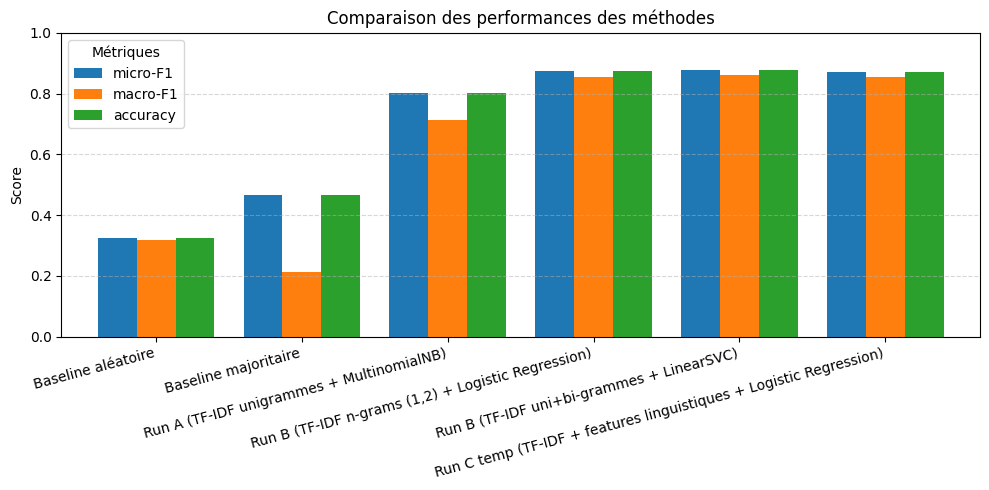

In [185]:
plot_df = results_df.set_index("Méthode")

ax = plot_df.plot(kind="bar", figsize=(10, 5), width=0.8)

plt.title("Comparaison des performances des méthodes")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Métriques")
plt.tight_layout()

plt.savefig("../plots/comparaison_methodes.png", dpi=300, bbox_inches="tight")
plt.show()

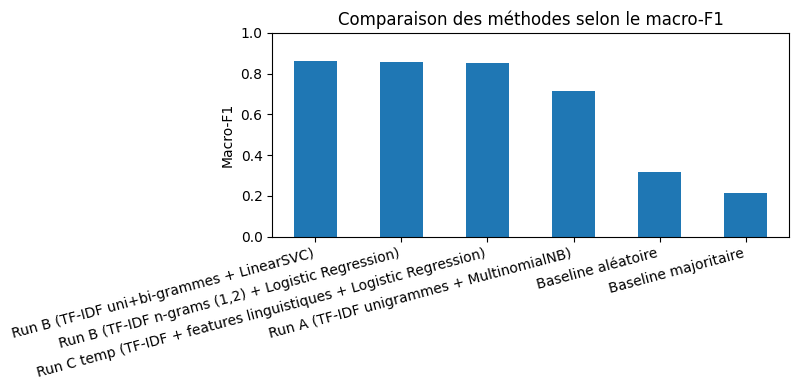

In [184]:
results_df.sort_values("macro-F1", ascending=False).plot(
    x="Méthode",
    y="macro-F1",
    kind="bar",
    figsize=(8, 4),
    legend=False
)

plt.title("Comparaison des méthodes selon le macro-F1")
plt.ylabel("Macro-F1")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

plt.savefig("../plots/comparaison_macro_f1.png", dpi=300, bbox_inches="tight")
plt.show()